In [18]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

'2.12.1'

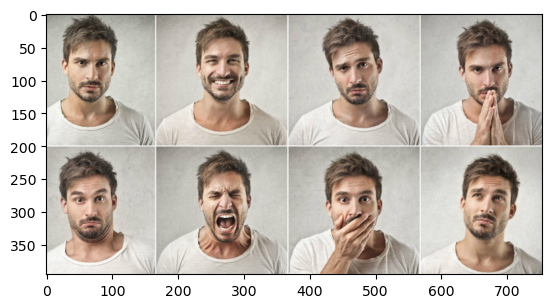

In [20]:
# caminho para a imagem a ser carregada
img_path = '../Material/Material/testes/teste02.jpg'
img = cv2.imread(img_path)

# tive que alterar o tipo da cor para mostrar no pyplot inves de usar a lib padrao do cv2 que estava dando erro
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# mostrando a imagem
plt.imshow(img_rgb)
plt.show()

In [21]:
# modelo para detectar faces
cascade_faces = '../Material/Material/haarcascade_frontalface_default.xml'
# caminho para o modelo treinado para identificar emoções
path_model = '../Material/Material/modelo_01_expressoes.h5'

# carregando os objetos de reconhecimento de faces e emoções com os modelos
face_detection = cv2.CascadeClassifier(cascade_faces)
emotion_class = load_model(path_model, compile = False)

# expressoes faciais
exp = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Triste', 'Surpreso', 'Neutro']

In [22]:
# fazendo a detecção de faces
faces = face_detection.detectMultiScale(img,
                                        scaleFactor=1.1,
                                        minNeighbors=3,
                                        minSize=(20,20))

In [23]:
# vendo se reconheceu as 8 faces
len(faces)

8

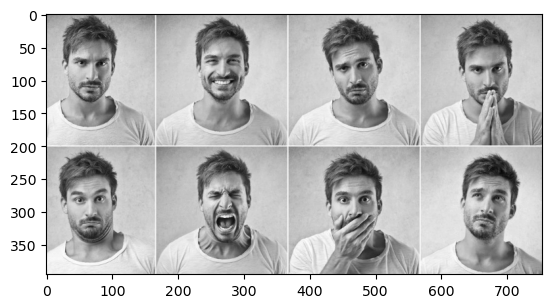

In [24]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

In [ ]:

# criando copia da imagem
original = img.copy()
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

1/1 [==============================] - 0s 23ms/step


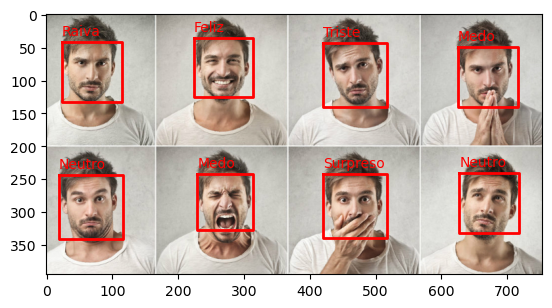

In [33]:
# define a imagem para mostrar
plt.imshow(original_rgb)

# loop para fazer as previsões para cada face identificada
for (x, y, w, h) in faces:
    
    # pegando a area de interesse
    roi = gray[y:y + h, x:x + w]

    # deixando no tamanho correto
    roi = cv2.resize(roi, (48, 48))


    # normalizando as faces
    roi = roi.astype('float')
    roi = roi / 255
    roi = img_to_array(roi)
    roi = np.expand_dims(roi, axis=0)

    # fazendo as previsoes das faces
    preds = emotion_class.predict(roi)[0]
    # vendo a emoção mais provável
    emotion_probability = np.max(preds)
    # label da expressao
    label = exp[preds.argmax()]


    # Resultados
    # coordenadas das linhas para fechar o retangulo
    x_coords = [x, x + w, x + w, x, x]
    y_coords = [y, y, y + h, y + h, y]
    # desenhando o quadrado
    plt.plot(x_coords, y_coords, color='red', linewidth=2)
    # coloando o texto
    plt.text(x, y - 10, label, color='red')
    
plt.show()